# 06 - At-Risk Learner Modeling

This notebook builds the **early-warning modeling branch** of the final project.
It uses only the **day-30-safe feature store** from notebook `04_feature_engineering.ipynb`, then enriches the model with the **segment outputs from notebook 05** for stronger interpretation.

## Goals
1. Build and compare multiple candidate models for identifying at-risk learners.
2. Choose an operating threshold aligned with the project objective: **high recall for early intervention**.
3. Interpret the final model with feature importance and cluster-level diagnostics.
4. Export prediction and performance tables for reporting, Power BI, and management discussion.

## Modeling target
`at_risk = 1` if the learner's final outcome is `Fail` or `Withdrawn`, and `0` otherwise.


In [1]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 11


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root.')


ROOT = find_repo_root()
PROCESSED = ROOT / 'data' / 'processed'

KEY = ['id_student', 'code_module', 'code_presentation']
TARGET_COL = 'at_risk'
TARGET_RECALL = 0.90
RANDOM_STATE = 42
THRESHOLD_GRID = np.arange(0.20, 0.66, 0.05)
OUTCOME_ORDER = ['Distinction', 'Pass', 'Fail', 'Withdrawn']

print(f'Repository root: {ROOT}')
print(f'Processed directory: {PROCESSED}')


Repository root: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project
Processed directory: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project/data/processed


## 1. Load and prepare the modeling dataset

The core predictive table comes from `features_prediction.csv`.
To make the modeling branch more useful for explanation and post-model intervention design, we also merge:

- `cluster_label` from notebook 05,
- `rule_segment` from notebook 05,
- `final_result` for evaluation and diagnostic slicing only.

Both segment fields are derived from the same day-30 information window, so they remain compatible with the early-warning design.


In [2]:
features_prediction = pd.read_csv(PROCESSED / 'features_prediction.csv', low_memory=False)
segment_assignments = pd.read_csv(PROCESSED / 'segment_assignments.csv', low_memory=False)

modeling_df = features_prediction.merge(
    segment_assignments[KEY + ['cluster_label', 'rule_segment', 'final_result']],
    on=KEY,
    how='left',
)

inventory = pd.DataFrame([
    {'dataset': 'features_prediction', 'rows': len(features_prediction), 'columns': features_prediction.shape[1], 'role': 'Model-ready numerical and one-hot encoded feature table'},
    {'dataset': 'segment_assignments', 'rows': len(segment_assignments), 'columns': segment_assignments.shape[1], 'role': 'Cluster and rule-based segments from notebook 05'},
    {'dataset': 'modeling_df', 'rows': len(modeling_df), 'columns': modeling_df.shape[1], 'role': 'Merged early-warning dataset for notebook 06'},
])
display(inventory)

print('Target distribution:')
print(modeling_df[TARGET_COL].value_counts(normalize=True).rename({0: 'Not at risk', 1: 'At risk'}).round(4).to_string())
print()
print('Final result distribution:')
print(modeling_df['final_result'].value_counts().reindex(OUTCOME_ORDER).to_string())


,dataset,rows,columns,role
0,features_prediction,32593,39,Model-ready numerical and one-hot encoded feat...
1,segment_assignments,32593,10,Cluster and rule-based segments from notebook 05
2,modeling_df,32593,42,Merged early-warning dataset for notebook 06


Target distribution:
at_risk
At risk       0.5280
Not at risk   0.4720

Final result distribution:
final_result
Distinction     3024
Pass           12361
Fail            7052
Withdrawn      10156


In [3]:
# Add notebook-05 segment information as model inputs.
modeling_df = pd.get_dummies(
    modeling_df,
    columns=['cluster_label', 'rule_segment'],
    drop_first=True,
    dtype=int,
)

# XGBoost rejects feature names containing symbols such as <=, %, spaces, or hyphens.
# We therefore keep a mapping between original names and sanitized names.
original_columns = modeling_df.columns.tolist()
sanitize_map = {col: re.sub(r'[^0-9a-zA-Z_]+', '_', col) for col in modeling_df.columns}
modeling_df = modeling_df.rename(columns=sanitize_map)
reverse_feature_map = {sanitized: original for original, sanitized in sanitize_map.items()}

feature_catalog = pd.DataFrame({
    'sanitized_name': [col for col in modeling_df.columns if col not in KEY + [TARGET_COL, 'final_result']],
    'original_name': [reverse_feature_map[col] for col in modeling_df.columns if col not in KEY + [TARGET_COL, 'final_result']],
})
display(feature_catalog.head(20))


,sanitized_name,original_name
0,total_clicks_log,total_clicks_log
1,active_days_log,active_days_log
2,early_engagement_log,early_engagement_log
3,early_engagement_ratio,early_engagement_ratio
4,days_since_last,days_since_last
5,avg_score,avg_score
6,score_std,score_std
7,avg_submission_delay,avg_submission_delay
8,has_submission_by_day30,has_submission_by_day30
9,engagement_intensity_log,engagement_intensity_log


## 2. Train / validation / test design

The workflow uses a **60 / 20 / 20 stratified split**:
- `train`: fit the candidate models
- `validation`: choose the operating threshold and compare models fairly
- `test`: report the final held-out performance

This structure is intentionally stricter than fitting and evaluating on a single split.


In [4]:
meta_cols = KEY + ['final_result']
meta_df = modeling_df[meta_cols].copy()
X = modeling_df.drop(columns=meta_cols + [TARGET_COL])
y = modeling_df[TARGET_COL].copy()

X_train_full, X_test, y_train_full, y_test, meta_train_full, meta_test = train_test_split(
    X, y, meta_df,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X_train_full, y_train_full, meta_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame([
    {'split': 'Train', 'rows': len(X_train), 'at_risk_rate': y_train.mean()},
    {'split': 'Validation', 'rows': len(X_val), 'at_risk_rate': y_val.mean()},
    {'split': 'Test', 'rows': len(X_test), 'at_risk_rate': y_test.mean()},
])
display(split_summary.assign(at_risk_rate=lambda df: df['at_risk_rate'] * 100).round(2))

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight estimate for gradient boosting: {scale_pos_weight:.4f}')
print(f'Number of model features: {X.shape[1]}')


,split,rows,at_risk_rate
0,Train,19555,52.7900
1,Validation,6519,52.8000
2,Test,6519,52.8000


scale_pos_weight estimate for gradient boosting: 0.8941
Number of model features: 41


## 3. Candidate models

We compare three candidate models that fit the project scope from the proposal:

1. **Logistic Regression**: interpretable linear baseline.
2. **Random Forest**: strong nonlinear baseline with robust recall behavior.
3. **XGBoost**: boosted tree model for stronger ranking power and probability separation.

The business goal is **early intervention**, so the comparison does not stop at ROC-AUC. We also consider recall and a recall-oriented `F2` score.


In [5]:
candidate_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=4000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.80,
        colsample_bytree=0.80,
        scale_pos_weight=1.12 * scale_pos_weight,
        min_child_weight=2,
        reg_lambda=1.5,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=4,
    ),
}

for name, model in candidate_models.items():
    print(f'{name}: {model.__class__.__name__}')


Logistic Regression: LogisticRegression
Random Forest: RandomForestClassifier
XGBoost: XGBClassifier


## 4. Threshold-aware evaluation helpers

A threshold of `0.50` is not automatically optimal for this project.
Instead, we search over a threshold grid and choose the operating point using the following rule on the **validation split**:

1. keep thresholds with `recall >= 0.90`,
2. among those, maximize `precision`,
3. break ties with `F2`, then `ROC-AUC`.

This gives a more defendable early-warning decision rule than simply maximizing accuracy.


In [6]:
def fbeta_from_precision_recall(precision: float, recall: float, beta: float = 2.0) -> float:
    if precision == 0 and recall == 0:
        return 0.0
    return (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)


def evaluate_threshold(y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_from_precision_recall(precision, recall, beta=2.0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'f2': f2,
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }


def choose_operating_point(validation_rows: list[dict], target_recall: float = TARGET_RECALL) -> dict:
    eligible = [row for row in validation_rows if row['recall'] >= target_recall]
    candidate_pool = eligible if eligible else validation_rows
    return max(candidate_pool, key=lambda row: (row['precision'], row['f2'], row['roc_auc']))


## 5. Validation search across candidate models


In [7]:
fitted_models = {}
validation_search_rows = []
selected_validation_points = []
validation_probabilities = {}
test_probabilities = {}

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    validation_probabilities[model_name] = val_prob
    test_probabilities[model_name] = test_prob

    model_rows = []
    for threshold in THRESHOLD_GRID:
        row = evaluate_threshold(y_val, val_prob, threshold)
        row['model'] = model_name
        validation_search_rows.append(row)
        model_rows.append(row)

    selected = choose_operating_point(model_rows, target_recall=TARGET_RECALL)
    selected_validation_points.append(selected | {'model': model_name})

validation_search = pd.DataFrame(validation_search_rows)
selected_validation_table = pd.DataFrame(selected_validation_points).sort_values(['precision', 'f2', 'roc_auc'], ascending=False)
display(selected_validation_table[['model', 'threshold', 'precision', 'recall', 'f1', 'f2', 'roc_auc', 'pr_auc']].round(4))


,model,threshold,precision,recall,f1,f2,roc_auc,pr_auc
1,Random Forest,0.3000,0.6436,0.9024,0.7513,0.8352,0.8217,0.8562
2,XGBoost,0.2500,0.6303,0.9227,0.7490,0.8444,0.8293,0.8640
0,Logistic Regression,0.2500,0.6197,0.9137,0.7385,0.8345,0.7956,0.8289


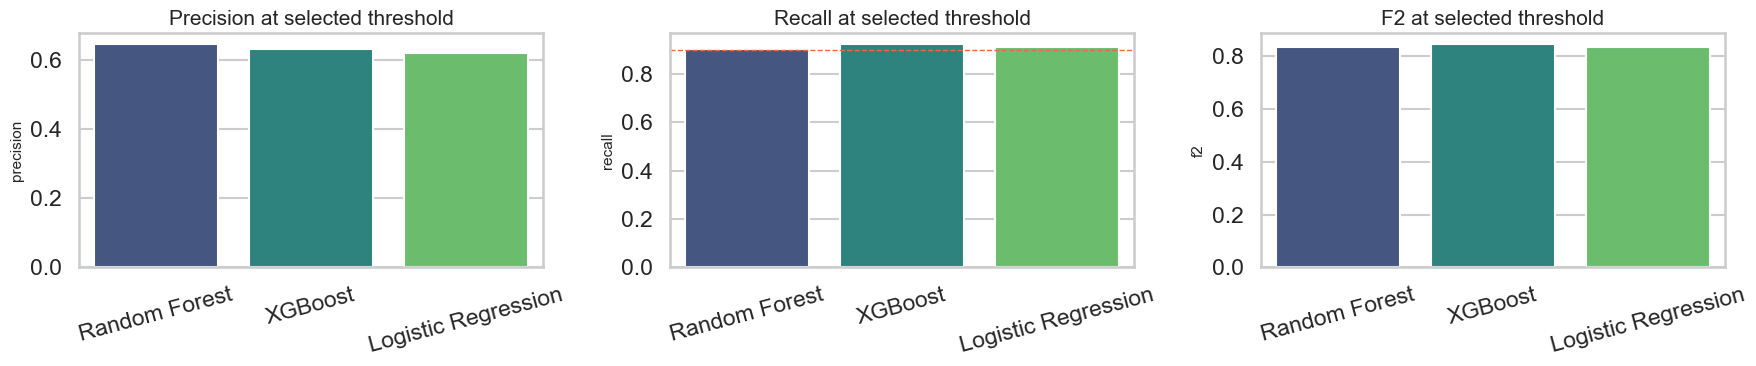

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

plot_cols = ['precision', 'recall', 'f2']
plot_titles = ['Precision at selected threshold', 'Recall at selected threshold', 'F2 at selected threshold']
for ax, col, title in zip(axes, plot_cols, plot_titles):
    sns.barplot(data=selected_validation_table, x='model', y=col, ax=ax, palette='viridis')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(TARGET_RECALL if col == 'recall' else 0, color='tomato' if col == 'recall' else 'none', linestyle='--', linewidth=1)

plt.tight_layout()


## 6. Select the final model

The final champion model is chosen from the validation operating points using the same early-warning logic:

- satisfy the recall-oriented objective,
- then prefer higher precision,
- then prefer stronger `F2` and ranking quality.


In [9]:
champion_row = selected_validation_table.sort_values(['precision', 'f2', 'roc_auc'], ascending=False).iloc[0].to_dict()
CHAMPION_MODEL_NAME = champion_row['model']
CHAMPION_THRESHOLD = float(champion_row['threshold'])
champion_model = fitted_models[CHAMPION_MODEL_NAME]

print(f'Champion model: {CHAMPION_MODEL_NAME}')
print(f'Chosen operating threshold: {CHAMPION_THRESHOLD:.2f}')
print('Validation operating point:')
champion_display = pd.DataFrame([champion_row])[['precision', 'recall', 'f1', 'f2', 'roc_auc', 'pr_auc']].astype(float)
display(champion_display.round(4))


Champion model: Random Forest
Chosen operating threshold: 0.30
Validation operating point:


,precision,recall,f1,f2,roc_auc,pr_auc
0,0.6436,0.9024,0.7513,0.8352,0.8217,0.8562


In [10]:
# Evaluate every model on the held-out test set at its own selected validation threshold.
test_comparison_rows = []
for _, row in selected_validation_table.iterrows():
    model_name = row['model']
    threshold = float(row['threshold'])
    test_eval = evaluate_threshold(y_test, test_probabilities[model_name], threshold)
    test_eval['model'] = model_name
    test_eval['selected_threshold'] = threshold
    test_comparison_rows.append(test_eval)

test_model_comparison = pd.DataFrame(test_comparison_rows).sort_values(['precision', 'f2', 'roc_auc'], ascending=False)
display(test_model_comparison[['model', 'selected_threshold', 'accuracy', 'precision', 'recall', 'f1', 'f2', 'roc_auc', 'pr_auc']].round(4))


,model,selected_threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,Random Forest,0.3000,0.6987,0.6532,0.9155,0.7624,0.8474,0.8427,0.8720
1,XGBoost,0.2500,0.6777,0.6324,0.9306,0.7530,0.8504,0.8462,0.8767
2,Logistic Regression,0.2500,0.6653,0.6239,0.9218,0.7441,0.8415,0.8178,0.8454


## 7. Final test-set evaluation of the champion


In [11]:
champion_val_prob = validation_probabilities[CHAMPION_MODEL_NAME]
champion_test_prob = test_probabilities[CHAMPION_MODEL_NAME]

champion_val_metrics = evaluate_threshold(y_val, champion_val_prob, CHAMPION_THRESHOLD)
champion_test_metrics = evaluate_threshold(y_test, champion_test_prob, CHAMPION_THRESHOLD)
champion_test_pred = (champion_test_prob >= CHAMPION_THRESHOLD).astype(int)

final_metrics_table = pd.DataFrame([
    {'split': 'Validation', **{k: v for k, v in champion_val_metrics.items() if k not in {'tn', 'fp', 'fn', 'tp'}}},
    {'split': 'Test', **{k: v for k, v in champion_test_metrics.items() if k not in {'tn', 'fp', 'fn', 'tp'}}},
])
display(final_metrics_table[['split', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'f2', 'roc_auc', 'pr_auc']].round(4))

print('Test confusion matrix counts:')
print(pd.Series({
    'TN': champion_test_metrics['tn'],
    'FP': champion_test_metrics['fp'],
    'FN': champion_test_metrics['fn'],
    'TP': champion_test_metrics['tp'],
}).to_string())


,split,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,Validation,0.3000,0.6846,0.6436,0.9024,0.7513,0.8352,0.8217,0.8562
1,Test,0.3000,0.6987,0.6532,0.9155,0.7624,0.8474,0.8427,0.8720


Test confusion matrix counts:
TN    1404
FP    1673
FN     291
TP    3151


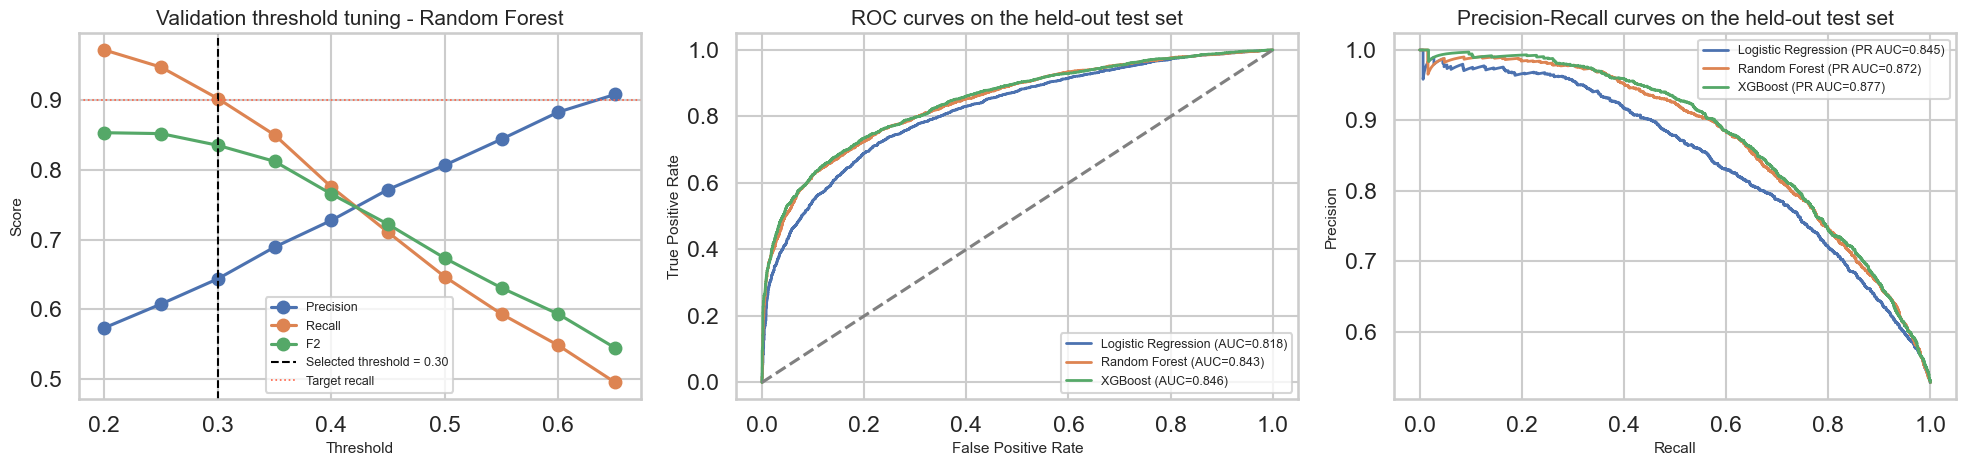

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Threshold curve for the champion on validation data
champion_threshold_curve = validation_search[validation_search['model'].eq(CHAMPION_MODEL_NAME)].copy()
axes[0].plot(champion_threshold_curve['threshold'], champion_threshold_curve['precision'], marker='o', label='Precision')
axes[0].plot(champion_threshold_curve['threshold'], champion_threshold_curve['recall'], marker='o', label='Recall')
axes[0].plot(champion_threshold_curve['threshold'], champion_threshold_curve['f2'], marker='o', label='F2')
axes[0].axvline(CHAMPION_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Selected threshold = {CHAMPION_THRESHOLD:.2f}')
axes[0].axhline(TARGET_RECALL, color='tomato', linestyle=':', linewidth=1.2, label='Target recall')
axes[0].set_title(f'Validation threshold tuning - {CHAMPION_MODEL_NAME}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9)

# 2. ROC curves on the test set
for model_name in candidate_models:
    fpr, tpr, _ = roc_curve(y_test, test_probabilities[model_name])
    auc = roc_auc_score(y_test, test_probabilities[model_name])
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_title('ROC curves on the held-out test set')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

# 3. Precision-recall curves on the test set
for model_name in candidate_models:
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probabilities[model_name])
    pr_auc = average_precision_score(y_test, test_probabilities[model_name])
    axes[2].plot(recall_curve, precision_curve, linewidth=2, label=f'{model_name} (PR AUC={pr_auc:.3f})')
axes[2].set_title('Precision-Recall curves on the held-out test set')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=9)

plt.tight_layout()


## 8. Feature importance and interpretation

To avoid over-relying on a single importance measure, the notebook reports two views for the champion model:

1. **Native model importance** (fast, model-specific)
2. **Permutation importance on validation ROC-AUC** (slower, more diagnostic)

This combination is more defensible for the final report than showing only one ranking.


In [13]:
if hasattr(champion_model, 'feature_importances_'):
    native_importance = pd.DataFrame({
        'feature': X.columns,
        'native_importance': champion_model.feature_importances_,
    }).sort_values('native_importance', ascending=False)
else:
    native_importance = pd.DataFrame({'feature': X.columns, 'native_importance': np.nan})

native_importance['original_feature_name'] = native_importance['feature'].map(reverse_feature_map)

perm = permutation_importance(
    champion_model,
    X_val,
    y_val,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=1,
)
permutation_importance_df = pd.DataFrame({
    'feature': X.columns,
    'permutation_importance_mean': perm.importances_mean,
    'permutation_importance_std': perm.importances_std,
}).sort_values('permutation_importance_mean', ascending=False)
permutation_importance_df['original_feature_name'] = permutation_importance_df['feature'].map(reverse_feature_map)

model_feature_importance = native_importance.merge(
    permutation_importance_df[['feature', 'permutation_importance_mean', 'permutation_importance_std']],
    on='feature',
    how='left',
)
model_feature_importance = model_feature_importance[[
    'feature', 'original_feature_name', 'native_importance',
    'permutation_importance_mean', 'permutation_importance_std'
]].sort_values(['permutation_importance_mean', 'native_importance'], ascending=False)

display(model_feature_importance.head(15).round(5))


,feature,original_feature_name,native_importance,permutation_importance_mean,permutation_importance_std
0,avg_score,avg_score,0.1173,0.0293,0.0008
5,studied_credits,studied_credits,0.0548,0.0210,0.0002
1,days_since_last,days_since_last,0.1162,0.0159,0.0009
9,avg_submission_delay,avg_submission_delay,0.0411,0.0082,0.0008
2,learning_risk_index,learning_risk_index,0.1011,0.0080,0.0009
15,highest_education_Lower_Than_A_Level,highest_education_Lower Than A Level,0.0155,0.0078,0.0010
13,completion_ratio,completion_ratio,0.0228,0.0067,0.0005
10,assessment_discipline,assessment_discipline,0.0401,0.0061,0.0004
3,active_days_log,active_days_log,0.0896,0.0038,0.0008
4,total_clicks_log,total_clicks_log,0.0702,0.0030,0.0007


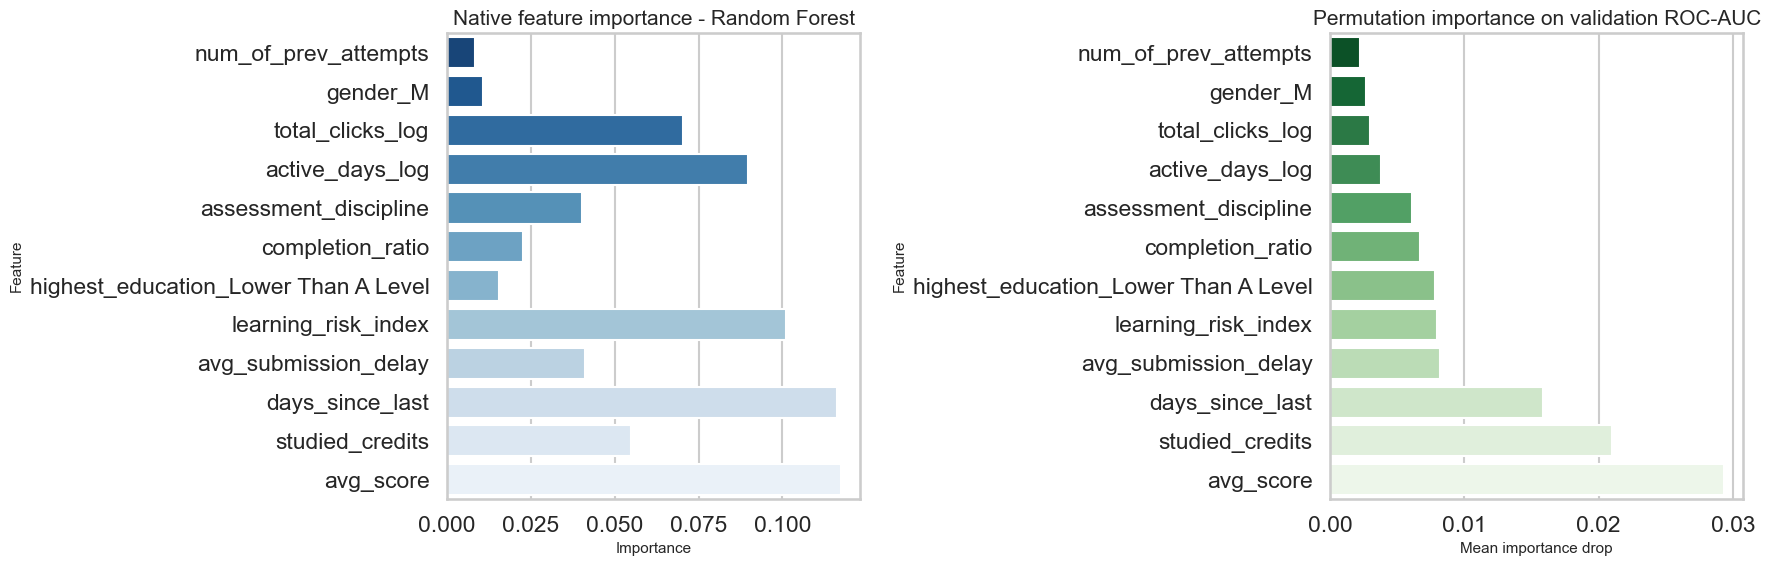

In [14]:
plot_importance = model_feature_importance.head(12).copy().sort_values('permutation_importance_mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=plot_importance, x='native_importance', y='original_feature_name', ax=axes[0], palette='Blues_r')
axes[0].set_title(f'Native feature importance - {CHAMPION_MODEL_NAME}')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

sns.barplot(data=plot_importance, x='permutation_importance_mean', y='original_feature_name', ax=axes[1], palette='Greens_r')
axes[1].set_title('Permutation importance on validation ROC-AUC')
axes[1].set_xlabel('Mean importance drop')
axes[1].set_ylabel('Feature')

plt.tight_layout()


## 9. Segment-level and outcome-level diagnostics

The final model should not only score well overall; it also needs to make sense across the learner groups discovered in notebook 05.
This section checks whether predictive behavior differs by cluster and by final outcome.


In [15]:
# Re-attach readable segment labels for test diagnostics.
segment_diag = pd.read_csv(PROCESSED / 'segment_assignments.csv', low_memory=False)[KEY + ['cluster_label', 'rule_segment']]

test_predictions = meta_test.copy()
test_predictions['y_true'] = y_test.values
test_predictions['risk_probability'] = champion_test_prob
test_predictions['y_pred'] = champion_test_pred
test_predictions['operating_threshold'] = CHAMPION_THRESHOLD
test_predictions['model_name'] = CHAMPION_MODEL_NAME
test_predictions = test_predictions.merge(segment_diag, on=KEY, how='left')

test_predictions['prediction_outcome'] = np.select(
    [
        (test_predictions['y_true'].eq(1) & test_predictions['y_pred'].eq(1)),
        (test_predictions['y_true'].eq(0) & test_predictions['y_pred'].eq(0)),
        (test_predictions['y_true'].eq(0) & test_predictions['y_pred'].eq(1)),
        (test_predictions['y_true'].eq(1) & test_predictions['y_pred'].eq(0)),
    ],
    ['True Positive', 'True Negative', 'False Positive', 'False Negative'],
    default='Unknown'
)

segment_model_performance = (
    test_predictions.groupby('cluster_label', observed=True)
    .apply(lambda g: pd.Series({
        'n': len(g),
        'actual_at_risk_rate': g['y_true'].mean(),
        'predicted_positive_rate': g['y_pred'].mean(),
        'average_risk_probability': g['risk_probability'].mean(),
        'precision': precision_score(g['y_true'], g['y_pred'], zero_division=0),
        'recall': recall_score(g['y_true'], g['y_pred'], zero_division=0),
        'accuracy': accuracy_score(g['y_true'], g['y_pred']),
    }))
    .reset_index()
    .sort_values('actual_at_risk_rate', ascending=False)
)

display(segment_model_performance.round(4))


,cluster_label,n,actual_at_risk_rate,predicted_positive_rate,average_risk_probability,precision,recall,accuracy
1,Inactive Drop-offs,"1,015.0000",0.9300,0.9990,0.9326,0.9300,0.9989,0.9291
2,Sporadic Explorers,"1,683.0000",0.6156,0.9281,0.6031,0.6504,0.9807,0.6637
3,Steady Progressors,"3,400.0000",0.3885,0.6059,0.3708,0.5316,0.8289,0.6497
0,Focused Achievers,421.0000,0.3349,0.4466,0.3084,0.5160,0.6879,0.6793


,n,predicted_positive_rate,average_risk_probability
final_result,,,
Distinction,601,0.3577,0.2763
Pass,2476,0.5889,0.3600
Fail,1425,0.8898,0.5700
Withdrawn,2017,0.9336,0.7351


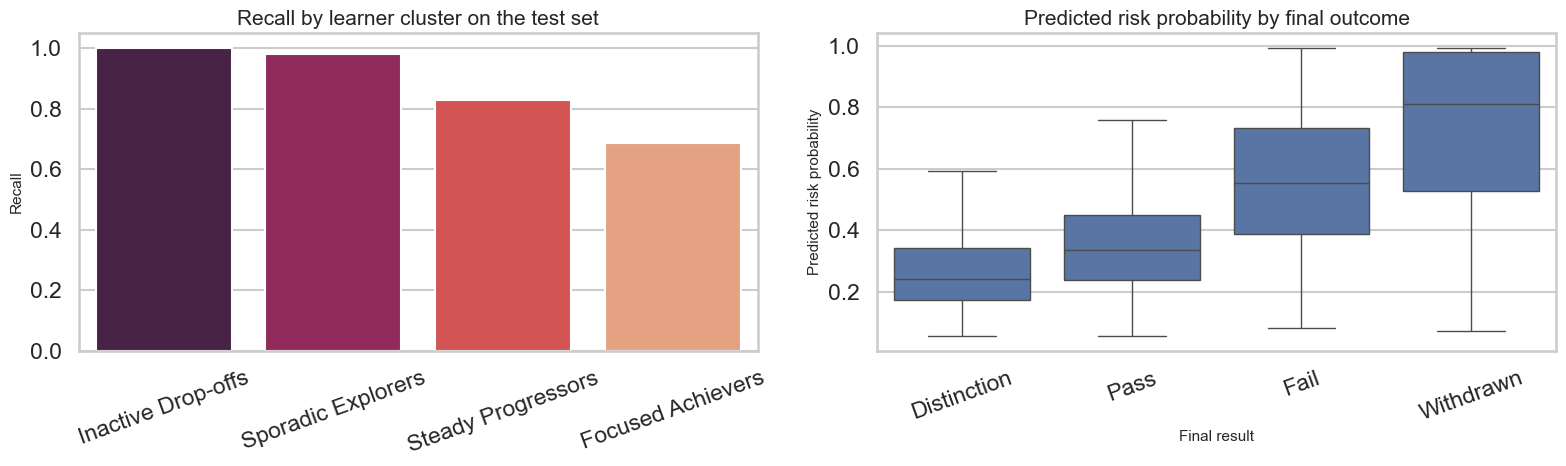

In [16]:
outcome_risk_summary = (
    test_predictions.groupby('final_result', observed=True)
    .agg(
        n=('id_student', 'size'),
        predicted_positive_rate=('y_pred', 'mean'),
        average_risk_probability=('risk_probability', 'mean'),
    )
    .reindex(OUTCOME_ORDER)
)

display(outcome_risk_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=segment_model_performance, x='cluster_label', y='recall', ax=axes[0], palette='rocket')
axes[0].set_title('Recall by learner cluster on the test set')
axes[0].set_xlabel('')
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=test_predictions, x='final_result', y='risk_probability', order=OUTCOME_ORDER, ax=axes[1], showfliers=False)
axes[1].set_title('Predicted risk probability by final outcome')
axes[1].set_xlabel('Final result')
axes[1].set_ylabel('Predicted risk probability')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()


## 10. Export outputs for reporting and Power BI

The notebook exports five reporting-ready artifacts:

- `model_validation_operating_points.csv`: selected operating point for each candidate model
- `threshold_search_validation.csv`: full validation threshold grid
- `model_test_comparison.csv`: held-out test results at the selected thresholds
- `at_risk_test_predictions.csv`: enrollment-level predictions for the held-out test set
- `model_feature_importance.csv`: feature ranking for interpretation
- `segment_model_performance.csv`: cluster-specific test performance
- `outcome_risk_summary.csv`: predicted risk by final result group


In [17]:
selected_validation_table.to_csv(PROCESSED / 'model_validation_operating_points.csv', index=False)
validation_search.to_csv(PROCESSED / 'threshold_search_validation.csv', index=False)
test_model_comparison.to_csv(PROCESSED / 'model_test_comparison.csv', index=False)
test_predictions.to_csv(PROCESSED / 'at_risk_test_predictions.csv', index=False)
model_feature_importance.to_csv(PROCESSED / 'model_feature_importance.csv', index=False)
segment_model_performance.to_csv(PROCESSED / 'segment_model_performance.csv', index=False)
outcome_risk_summary.reset_index().to_csv(PROCESSED / 'outcome_risk_summary.csv', index=False)

print('Saved outputs:')
print(f"  model_validation_operating_points.csv -> {selected_validation_table.shape}")
print(f"  threshold_search_validation.csv       -> {validation_search.shape}")
print(f"  model_test_comparison.csv             -> {test_model_comparison.shape}")
print(f"  at_risk_test_predictions.csv          -> {test_predictions.shape}")
print(f"  model_feature_importance.csv          -> {model_feature_importance.shape}")
print(f"  segment_model_performance.csv         -> {segment_model_performance.shape}")
print(f"  outcome_risk_summary.csv              -> {outcome_risk_summary.shape}")


Saved outputs:
  model_validation_operating_points.csv -> (3, 13)
  threshold_search_validation.csv       -> (30, 13)
  model_test_comparison.csv             -> (3, 14)
  at_risk_test_predictions.csv          -> (6519, 12)
  model_feature_importance.csv          -> (41, 5)
  segment_model_performance.csv         -> (4, 8)
  outcome_risk_summary.csv              -> (4, 3)


## 11. Conclusion and project handoff

### Final modeling takeaway
- The notebook compares a transparent linear baseline, a nonlinear ensemble baseline, and a boosted tree model.
- The final operating point is chosen with an **early-warning objective**, not a default threshold.
- This produces a model that is more useful for intervention planning than a classifier optimized only for accuracy.

### How to use this in the final project
1. Use the selected validation and test tables to justify the final model choice in the report.
2. Use `at_risk_test_predictions.csv` and `segment_model_performance.csv` in Power BI for the **At-Risk Learner Identification** and **At-Risk Behavior Deep Dive** pages.
3. Combine notebook 05 recommendations with notebook 06 predictions to build the final intervention narrative: **who is at risk, why they are at risk, and what should be recommended next**.
